In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('processed_data.csv')

X = df.drop(columns=['mental_health_risk'])
y = df['mental_health_risk']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 26)
y shape: (25000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures same split every time it is run
    stratify=y          # keeps class proportions same in train and test
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 20000
Testing samples: 5000


## Why We Split the data

We train the model on 80% of the data and test it on the remaining 20% 
that it has never seen. This tells us if the model actually learned 
patterns or just memorized the training data.

stratify=y ensures that all three risk classes are proportionally 
represented in both train and test sets.

In [7]:
# Model 1: Logistic regression:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\n=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, lr_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))

Training Logistic Regression...

=== LOGISTIC REGRESSION ===
Accuracy: 0.7484

Detailed Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.76      0.77      1871
 Medium Risk       0.71      0.78      0.75      2365
   High Risk       0.76      0.63      0.69       764

    accuracy                           0.75      5000
   macro avg       0.76      0.72      0.74      5000
weighted avg       0.75      0.75      0.75      5000



E:\anacondanavigator\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
#Model 2: Random forest:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))

Training Random Forest...

=== RANDOM FOREST ===
Accuracy: 0.9738

Detailed Report:
              precision    recall  f1-score   support

    Low Risk       0.99      1.00      0.99      1871
 Medium Risk       0.96      0.99      0.97      2365
   High Risk       0.98      0.88      0.93       764

    accuracy                           0.97      5000
   macro avg       0.98      0.95      0.96      5000
weighted avg       0.97      0.97      0.97      5000



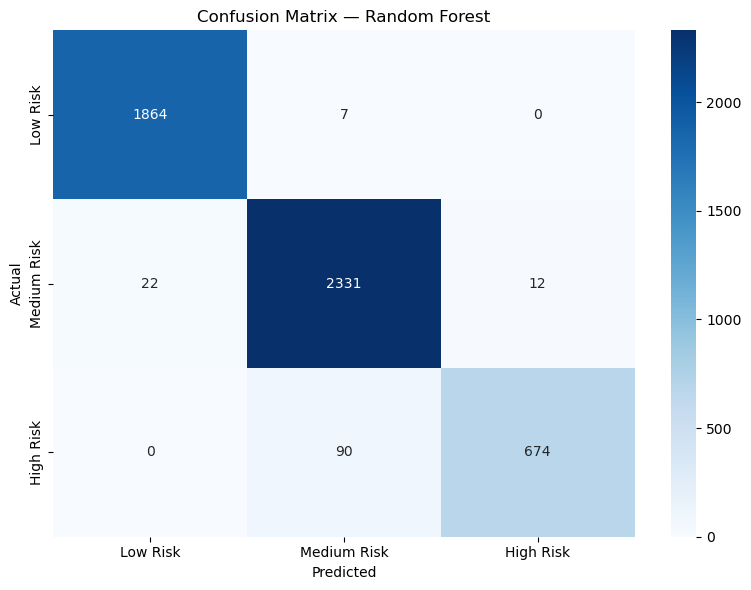

In [11]:
#Confusion matrix for random forest
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'Medium Risk', 'High Risk'],
            yticklabels=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

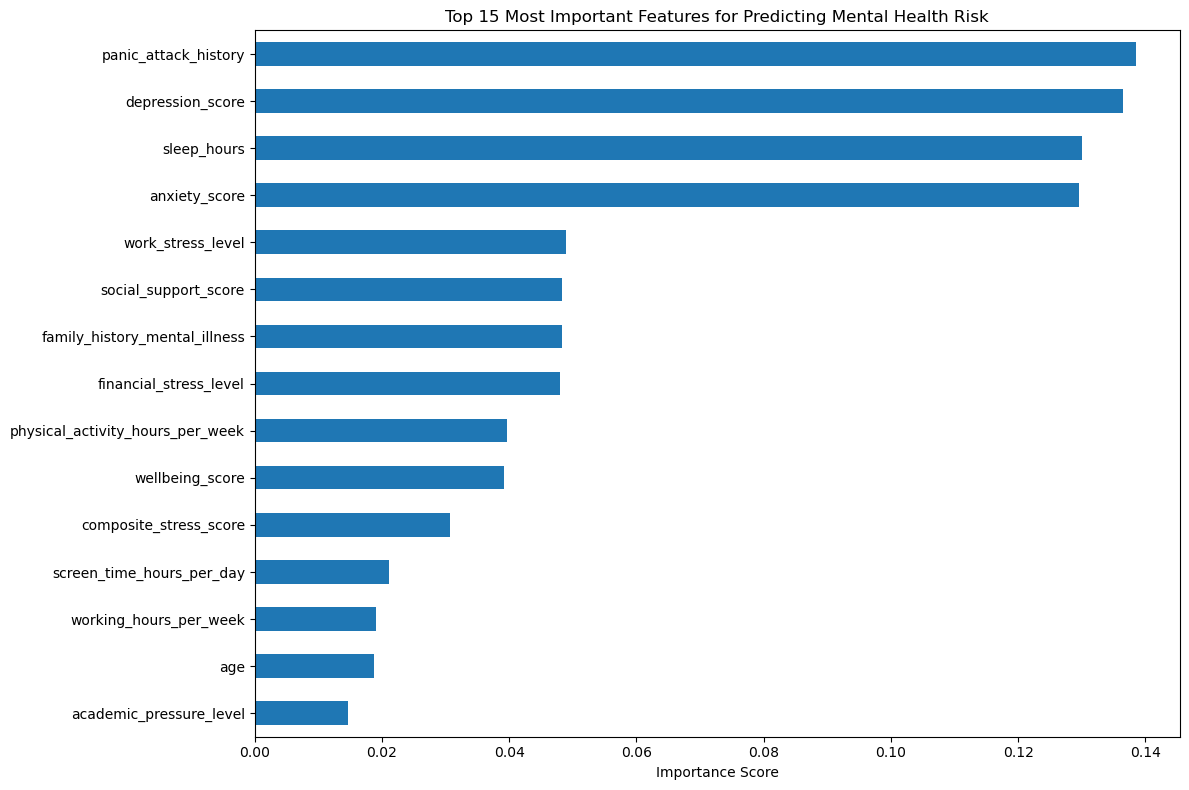


Top 5 most important features:
panic_attack_history    0.138504
depression_score        0.136476
sleep_hours             0.129961
anxiety_score           0.129617
work_stress_level       0.048926
dtype: float64


In [12]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importance_sorted.head(15).plot(kind='barh')
plt.title('Top 15 Most Important Features for Predicting Mental Health Risk')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_sorted.head())

MODEL COMPARISON:

LOGICAL REGRESSION-ACCURACY:74.84%
RANDOM FOREST-ACCURACE:97.38%
Random Forest outperforms Logistic Regression because it builds 
100 decision trees and combines their predictions, making it more 
robust to complex patterns in the data.


Most Important Features:

The top features for predicting mental health risk are:
1. panic_attack_history
2. depression_score  
3. sleep_hours

   
What the confusion matrix Tells Us:

The model performs best on Class 0 (Low Risk) and Class 1 (Medium Risk).
Class 2 (High Risk) is harder to predict correctly, likely because it 
has fewer training samples (class imbalance).